In [563]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Business probel:
- The medical insurance dataset encompasses various factors influencing medical expenses, such as age, sex, BMI, smoking status, number of children, and region. This dataset serves as a foundation for training machine learning models capable of forecasting medical expenses for new policyholders.

- Its purpose is to shed light on the pivotal elements contributing to increased insurance costs, aiding the company in making more informed decisions concerning pricing and risk assessment.

The dataset comprises 2.7K rows and 7 columns, including:

- Age
- Sex
- BMI (Body Mass Index)
- Children
- Smoker
- Region
- Charges
- Problem Statement:

- What are the primary factors influencing medical expenses?
- How accurate are machine learning models in predicting medical expenses?
- In what ways can machine learning models enhance the efficiency and profitability of health insurance companies?

# Data Understanding

In [564]:
df = pd.read_csv(r"C:\Users\SHRI\OneDrive\Desktop\DataScience_DataFiles\Medical Insurance Costs Dataset.csv")

In [565]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


In [566]:
df.shape

(2772, 7)

In [567]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [568]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [569]:
df.duplicated().sum()

1435

In [570]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.590,0,no,northwest,1639.56310
1338,23,male,34.400,0,no,southwest,1826.84300
1339,56,female,39.820,0,no,southeast,11090.71780
1340,27,male,42.130,0,yes,southeast,39611.75770
1341,19,male,24.600,1,no,southwest,1837.23700
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


In [571]:
df = df.drop_duplicates()

In [572]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [573]:
df['age'].unique()

array([19, 18, 28, 33, 32, 31, 46, 37, 60, 25, 62, 23, 56, 27, 52, 30, 34,
       59, 63, 55, 22, 26, 35, 24, 41, 38, 36, 21, 48, 40, 58, 53, 43, 64,
       20, 61, 44, 57, 29, 45, 54, 49, 47, 51, 42, 50, 39], dtype=int64)

In [574]:
df[['sex', 'region']].value_counts()

sex     region   
male    southeast    189
female  southeast    175
        northwest    164
male    northeast    163
        southwest    163
female  southwest    162
        northeast    161
male    northwest    160
Name: count, dtype: int64

# Data cleaning

In [575]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [576]:
df= df.rename(columns={'sex': "gender"})

In [577]:
df

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [578]:
df.dtypes

age           int64
gender       object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [579]:
df.columns

Index(['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [580]:
continous = ['age', 'bmi','charges']
categorical = ['gender', 'smoker', 'region']
count = ['children']

In [581]:
df[continous].skew()

age        0.054781
bmi        0.283914
charges    1.515391
dtype: float64

<Axes: xlabel='age', ylabel='Count'>

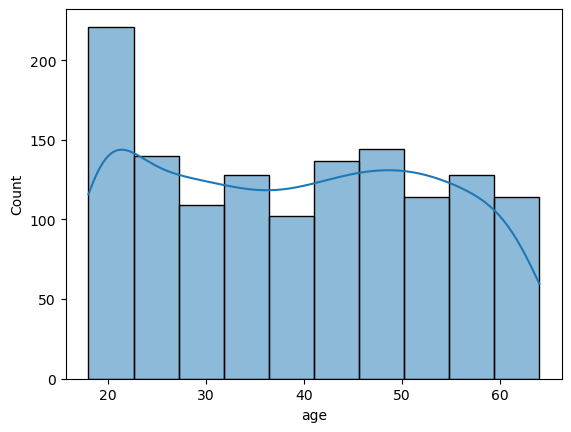

In [582]:
sns.histplot(df['age'], bins = 10, kde = True)

<Axes: xlabel='bmi', ylabel='Count'>

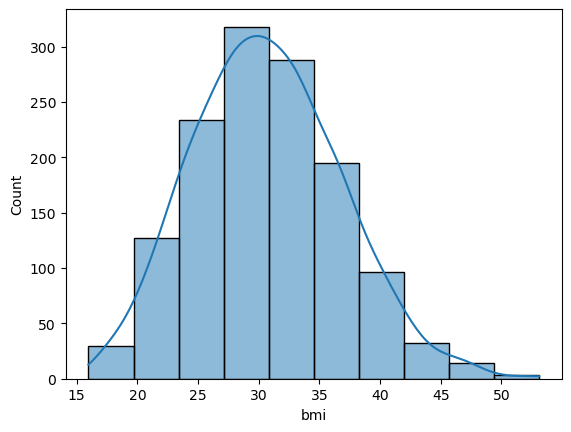

In [583]:
sns.histplot(df['bmi'], bins = 10, kde = True)

<Axes: xlabel='charges', ylabel='Count'>

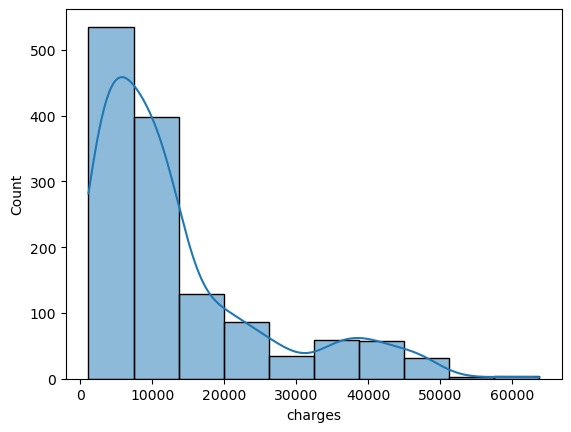

In [584]:
sns.histplot(df['charges'], bins = 10, kde = True)

<function matplotlib.pyplot.show(close=None, block=None)>

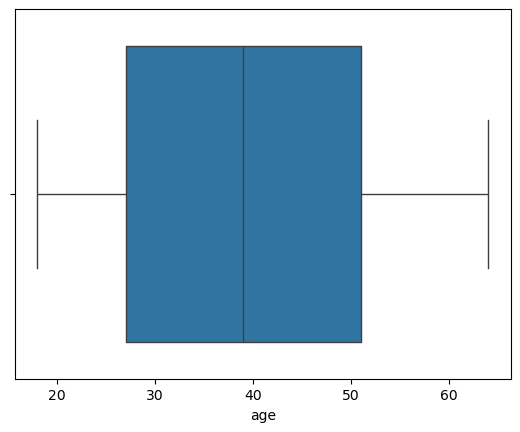

In [585]:
sns.boxplot(x = df['age'])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

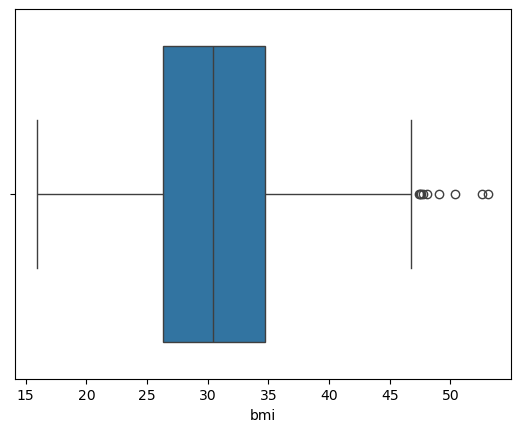

In [586]:
sns.boxplot(x = df['bmi'])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

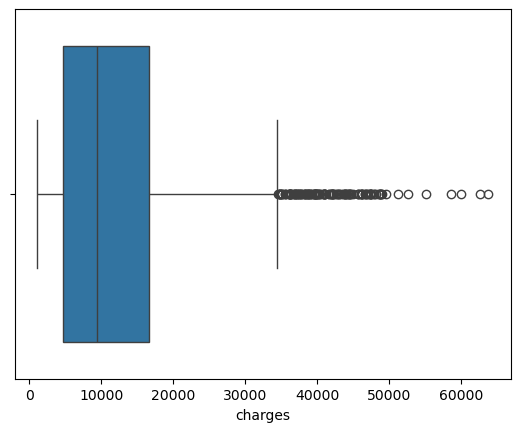

In [587]:
sns.boxplot(x = df['charges'])
plt.show

In [588]:
df['bmi'].min()

15.96

In [589]:
df['bmi'].max()

53.13

In [590]:
df[(df['bmi'] < df['bmi'].min()) | (df['bmi'] > df['bmi'].max())]

,age,gender,bmi,children,smoker,region,charges


In [591]:
df['charges'].min()

1121.8739

In [592]:
df['charges'].max()

63770.42801

In [593]:
df[(df['charges'] < df['charges'].min()) | (df['charges'] > df['charges'].max())]

,age,gender,bmi,children,smoker,region,charges


In [594]:
df.head()

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


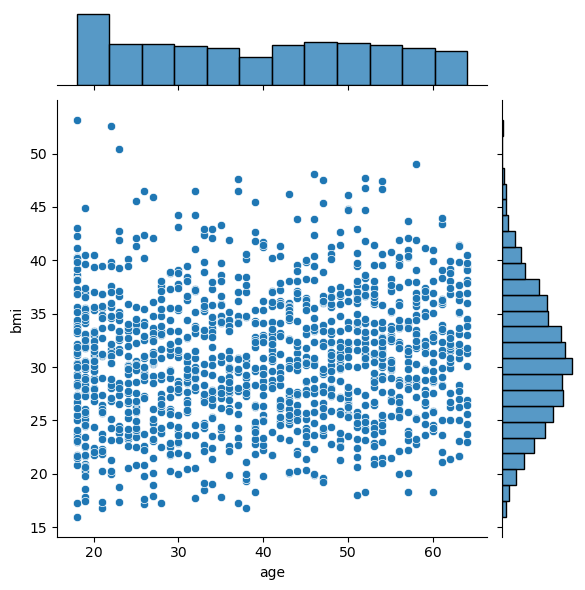

In [595]:
sns.jointplot(x = 'age', y = 'bmi', data = df)

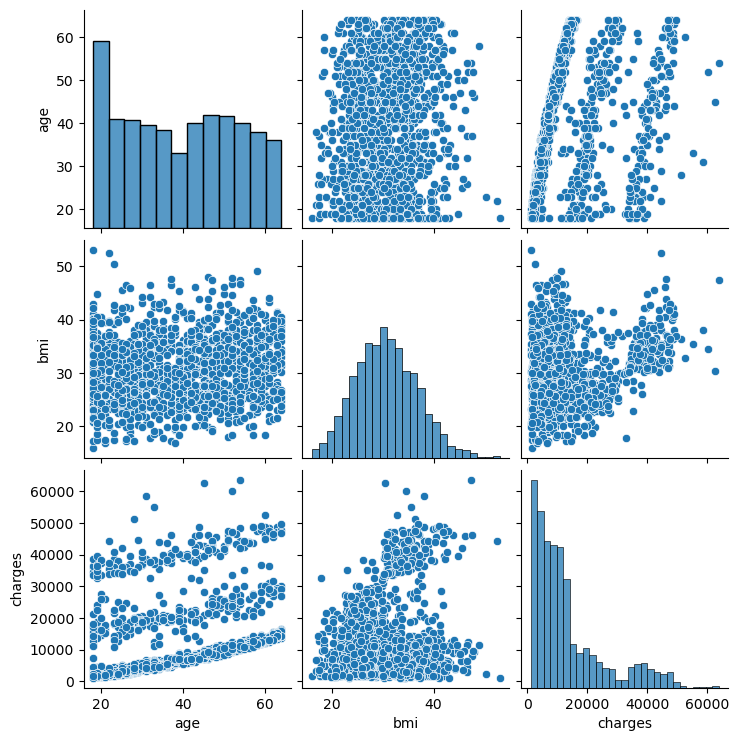

In [596]:
sns.pairplot(df, vars = continous)
plt.show()

<Axes: >

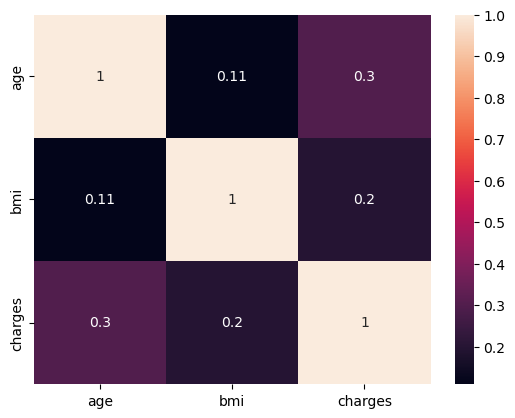

In [597]:
c_m = df[continous].corr()
sns.heatmap(c_m, annot = True)

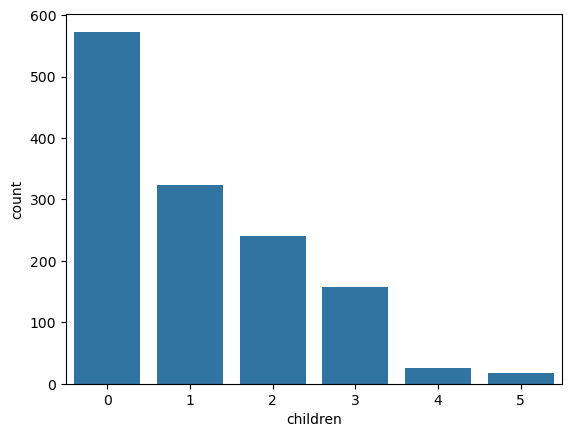

In [598]:
sns.countplot(x = 'children', data = df)
plt.show()

In [599]:
df.groupby('gender')['smoker'].count()

gender
female    662
male      675
Name: smoker, dtype: int64

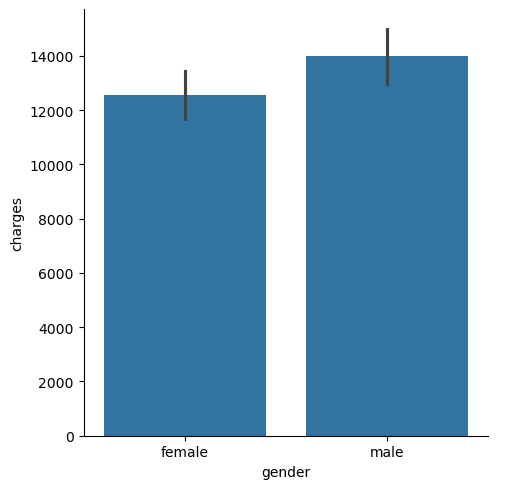

In [600]:
sns.catplot(x = 'gender', y = 'charges', data = df, kind = 'bar')

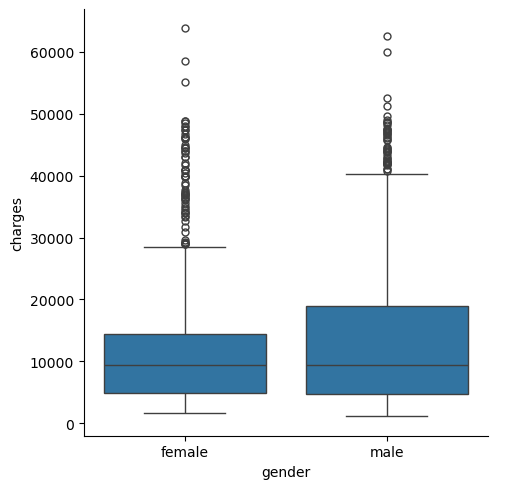

In [601]:
sns.catplot(x = 'gender', y = 'charges', data = df, kind = 'box')

In [602]:
pd.crosstab(df['gender'], df['region'] )

region,northeast,northwest,southeast,southwest
gender,,,,
female,161,164,175,162
male,163,160,189,163


In [603]:
pd.crosstab(df['gender'], df['smoker'] )

smoker,no,yes
gender,,
female,547,115
male,516,159


In [604]:
pd.crosstab(df['smoker'], df['region'] )

region,northeast,northwest,southeast,southwest
smoker,,,,
no,257,266,273,267
yes,67,58,91,58


In [605]:
from scipy.stats import boxcox

print("Skewness before Box-Cox transformation:", df['charges'].skew())

df['charges'], Param = boxcox(df['charges'])

print("Skewness after Box-Cox transformation:", df['charges'].skew())
print(f"Lambda used for transformation: {Param}")


Skewness before Box-Cox transformation: 1.5153909108403483
Skewness after Box-Cox transformation: -0.008674297022526162
Lambda used for transformation: 0.043516942579678274


In [606]:
df['charges'].skew()

-0.008674297022526162

# Encoding

In [607]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [608]:
label_encoder = LabelEncoder()
df['gender'] = label_encoder.fit_transform(df['gender'])
df['smoker'] = label_encoder.fit_transform(df['smoker'])


# One-hot encode the 'region' column (converts it into multiple columns, one for each region)
df = pd.get_dummies(df, columns=['region'], drop_first=True)  # drop_first avoids dummy variable trap


In [609]:
# Convert Boolean columns to 0 or 1
df['region_northwest'] = df['region_northwest'].astype(int)
df['region_southeast'] = df['region_southeast'].astype(int)
df['region_southwest'] = df['region_southwest'].astype(int)


In [610]:
df

,age,gender,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,12.120634,0,0,1
1,18,1,33.770,1,0,8.804026,0,1,0
2,28,1,33.000,3,0,10.141549,0,1,0
3,33,1,22.705,0,0,12.526076,1,0,0
4,32,1,28.880,0,0,9.939887,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,11.416735,1,0,0
1334,18,0,31.920,0,0,9.145579,0,0,0
1335,18,0,36.850,0,0,8.725190,0,1,0
1336,21,0,25.800,0,0,9.014352,0,0,1


In [611]:
df.dtypes

age                   int64
gender                int32
bmi                 float64
children              int64
smoker                int32
charges             float64
region_northwest      int32
region_southeast      int32
region_southwest      int32
dtype: object

# Train - Test split

In [612]:
# Separating the features and target variable

X = df[['age', 'gender', 'bmi', 'children', 'smoker']]
y = df['charges']


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)



Training Features Shape: (1069, 5)
Testing Features Shape: (268, 5)
Training Target Shape: (1069,)
Testing Target Shape: (268,)


In [613]:
df

,age,gender,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,12.120634,0,0,1
1,18,1,33.770,1,0,8.804026,0,1,0
2,28,1,33.000,3,0,10.141549,0,1,0
3,33,1,22.705,0,0,12.526076,1,0,0
4,32,1,28.880,0,0,9.939887,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,11.416735,1,0,0
1334,18,0,31.920,0,0,9.145579,0,0,0
1335,18,0,36.850,0,0,8.725190,0,1,0
1336,21,0,25.800,0,0,9.014352,0,0,1


In [614]:
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Linear Regression


In [615]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [616]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [617]:
slope = model.coef_[0]
intercept = model.intercept_

print('slope: ', slope)
print('intercept: ',intercept )

slope:  0.6966817726736787
intercept:  11.179279875282402


In [618]:
y_pred = model.predict(X_test)


In [619]:
y_pred

array([10.86167863, 10.59796913, 11.73456851, 12.90567533, 10.52493976,
       11.40609766, 12.50722941,  9.65239957, 11.03609449, 11.39859062,
       11.53923313, 13.39972362, 12.65506567, 11.93195912, 10.82353466,
       11.05591047,  9.74115323, 12.8811439 , 10.02416562, 10.23530679,
        9.70195347, 12.75814918, 11.59920915, 12.91223709, 12.69822722,
       10.04991722, 13.5166895 , 13.89130697, 11.25153144, 11.61136642,
       10.21648751, 11.30465994,  9.47563494, 11.58873133, 13.94749242,
       11.40974004, 10.2951692 , 10.40722095, 13.3387768 , 11.05535962,
        9.91818816, 13.21806717, 13.5302552 , 11.2726833 , 11.06019491,
        9.97686041,  9.72716556, 10.93769872, 10.12286106, 10.81956014,
       10.38765662, 10.70900818, 13.16394829,  9.60312366, 11.0282457 ,
       11.04023202, 11.19451523,  9.91486118, 12.74119824, 10.88914398,
       11.86584011, 10.61325105, 11.56087675,  9.38003212, 11.92689652,
       11.4738739 , 10.70682179, 12.95914467, 11.76243983, 12.00

In [620]:
y

0       12.120634
1        8.804026
2       10.141549
3       12.526076
4        9.939887
          ...    
1333    11.416735
1334     9.145579
1335     8.725190
1336     9.014352
1337    12.964199
Name: charges, Length: 1337, dtype: float64

In [621]:
# Evaluate the Model:

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print('mse : ', mse)
print('r2 : ', r2)

rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)



mse :  0.35891254880692314
r2 :  0.8252441390848306
Root Mean Squared Error (RMSE): 0.5990931052907579


In [622]:
# Display model coefficients
print(f'Coefficients: {model.coef_}')


Coefficients: [ 0.69668177 -0.05222139  0.10369286  0.17158516  0.9225704 ]


In [623]:
Relative_RMSE = rmse/df['charges'].mean()
Relative_RMSE

0.05352707131936959

In [624]:
feature_columns = X.columns
print("Feature Columns:", feature_columns)

Feature Columns: Index(['age', 'gender', 'bmi', 'children', 'smoker'], dtype='object')
